# ResNet — Fase 2 (versão completa)

Pipeline completo para os 3 melhores modelos da fase 1:
1. Ablation study para cada modelo
2. Só inclui técnicas que superam o baseline da fase 1
3. Treina modelo combinado final por arquitectura
4. Gera CSV individual por modelo
5. Ensemble dos 3 modelos finais + CSV

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys
import copy
import time
import random
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

sys.path.append(os.path.abspath("../src"))
from dataset import ButterflyDataset
from transforms import get_transforms

os.makedirs("../outputs/figures",     exist_ok=True)
os.makedirs("../outputs/results",     exist_ok=True)
os.makedirs("../outputs/submissions", exist_ok=True)
os.makedirs("../outputs/models",      exist_ok=True)

/Users/ritapduarte/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps


In [2]:
# ── Dataset ────────────────────────────────────────────────────────────────────
path = kagglehub.competition_download('aca-butterflies')
competition_dir = path
train_dir = os.path.join(competition_dir, "train")
test_dir  = os.path.join(competition_dir, "test")
train_csv = os.path.join(competition_dir, "train.csv")

SAMPLE_SUBMISSION_PATH = "/Users/ritapduarte/4ano/2semestre/ACA/submission.csv"

df = pd.read_csv(train_csv)
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

classes      = sorted(df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
NUM_CLASSES  = len(classes)

train_df["label_idx"] = train_df["label"].map(class_to_idx).astype(int)
val_df["label_idx"]   = val_df["label"].map(class_to_idx).astype(int)

train_transform, val_transform, test_transform = get_transforms()

BATCH_SIZE = 32
train_dataset = ButterflyDataset(train_df, train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(val_df,   train_dir, transform=val_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {NUM_CLASSES}")

Train: 4159 | Val: 1040 | Classes: 75


In [3]:
# ── Funções auxiliares ─────────────────────────────────────────────────────────
def build_model(arch, num_classes):
    weights_map = {
        "resnet18": models.ResNet18_Weights.IMAGENET1K_V1,
        "resnet34": models.ResNet34_Weights.IMAGENET1K_V1,
        "resnet50": models.ResNet50_Weights.IMAGENET1K_V2,
    }
    model_fn_map = {
        "resnet18": models.resnet18,
        "resnet34": models.resnet34,
        "resnet50": models.resnet50,
    }
    model = model_fn_map[arch](weights=weights_map[arch])
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def get_criterion(loss_name, label_smoothing=0.0):
    if loss_name == "CrossEntropyLoss":
        return nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    elif loss_name == "MultiMarginLoss":
        return nn.MultiMarginLoss()
    raise ValueError(f"Loss '{loss_name}' não suportada.")


def get_optimizer(opt_name, params, lr, weight_decay=1e-4):
    if opt_name == "Adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif opt_name == "RMSprop":
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=0.9)
    raise ValueError(f"Optimizador '{opt_name}' não suportado.")


def cutmix_data(images, labels, alpha=1.0):
    lam         = np.random.beta(alpha, alpha)
    rand_index  = torch.randperm(images.size(0)).to(images.device)
    labels_a    = labels
    labels_b    = labels[rand_index]
    _, _, H, W  = images.shape
    cut_ratio   = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cx, cy      = np.random.randint(W), np.random.randint(H)
    x1, x2     = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2     = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
    images_mixed = images.clone()
    images_mixed[:, :, y1:y2, x1:x2] = images[rand_index, :, y1:y2, x1:x2]
    lam = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return images_mixed, labels_a, labels_b, lam


def train_epoch(model, loader, criterion, optimizer, device, use_cutmix=False):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_cutmix and np.random.rand() < 0.5:
            images, labels_a, labels_b, lam = cutmix_data(images, labels)
            outputs = model(images)
            loss    = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            all_labels.extend(labels_a.cpu().numpy())
        else:
            outputs = model(images)
            loss    = criterion(outputs, labels)
            all_labels.extend(labels.cpu().numpy())

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())

    return (running_loss / len(loader.dataset),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro", zero_division=0))


def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            running_loss  += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (running_loss / len(loader.dataset),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro", zero_division=0))


def train_model(model, criterion, optimizer, train_loader, val_loader,
                device, num_epochs=20, patience=5, scheduler=None,
                use_cutmix=False, label="run"):
    history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","train_f1","val_f1"]}
    best_val_acc, best_weights, patience_count = 0.0, None, 0
    t_start = time.time()

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc, t_f1 = train_epoch(model, train_loader, criterion, optimizer, device, use_cutmix)
        v_loss, v_acc, v_f1 = val_epoch(model, val_loader, criterion, device)

        if scheduler:
            scheduler.step()

        for k, v in zip(history.keys(), [t_loss, v_loss, t_acc, v_acc, t_f1, v_f1]):
            history[k].append(v)

        print(f"  [{label}] Epoch {epoch:02d}/{num_epochs} "
              f"| Val acc {v_acc:.4f}  F1 {v_f1:.4f}  Loss {v_loss:.4f}")

        if v_acc > best_val_acc:
            best_val_acc   = v_acc
            best_weights   = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping na epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    elapsed = time.time() - t_start
    best_f1 = max(history["val_f1"])
    print(f"  Melhor val acc: {best_val_acc:.4f} | Tempo: {elapsed:.1f}s")
    return model, history, best_val_acc, best_f1


def freeze_backbone(model):
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False

def unfreeze_layer(model, layer_name):
    for name, param in model.named_parameters():
        if layer_name in name:
            param.requires_grad = True

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def generate_submission(model, sample_submission_path, test_dir,
                        transform, idx_to_class, device,
                        batch_size=32, output_path=None, tta_transforms=None):
    """Gera CSV de submission. Se tta_transforms fornecido, usa TTA."""
    sample_df = pd.read_csv(sample_submission_path)
    test_df   = pd.DataFrame({"filename": sample_df["filename"]})
    model.eval()

    transforms_list = tta_transforms if tta_transforms else [transform]
    all_probs, filenames_out = None, None

    for tfm in transforms_list:
        dataset     = ButterflyDataset(test_df, test_dir, transform=tfm, is_test=True)
        loader      = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        probs_list, fnames_list = [], []

        with torch.no_grad():
            for images, fnames in loader:
                probs = torch.softmax(model(images.to(device)), dim=1).cpu().numpy()
                probs_list.append(probs)
                fnames_list.extend(fnames)

        probs_arr = np.vstack(probs_list)
        if all_probs is None:
            all_probs, filenames_out = probs_arr, fnames_list
        else:
            all_probs += probs_arr

    avg_probs   = all_probs / len(transforms_list)
    preds       = avg_probs.argmax(axis=1)
    labels_pred = [idx_to_class[p] for p in preds]
    sub         = pd.DataFrame({"filename": filenames_out, "label": labels_pred})

    if output_path:
        sub.to_csv(output_path, index=False)
        print(f"  Submission guardada: {output_path} ({len(sub)} linhas)")
    return sub, avg_probs, filenames_out


print("Funções auxiliares carregadas.")

Funções auxiliares carregadas.


In [4]:
# ── Configuração dos top 3 modelos da fase 1 ───────────────────────────────────
# Preenche com os valores reais da tabela da fase 1
TOP3 = [
    {"arch": "resnet18", "loss": "CrossEntropyLoss", "optimizer": "Adam",
     "baseline_acc": 0.9548, "baseline_f1": 0.9560, "id": "resnet18_CE_Adam"},
    {"arch": "resnet50", "loss": "CrossEntropyLoss", "optimizer": "Adam",
     "baseline_acc": 0.9462, "baseline_f1": 0.9471, "id": "resnet50_CE_Adam"},
    {"arch": "resnet50", "loss": "MultiMarginLoss",  "optimizer": "Adam",
     "baseline_acc": 0.9423, "baseline_f1": 0.9427, "id": "resnet50_MM_Adam"},
]

# Hiperparâmetros globais
LR_CANDIDATES  = [1e-3, 1e-4, 1e-5]
NUM_EPOCHS_LR  = 10
NUM_EPOCHS_ABL = 20
PATIENCE       = 5

# TTA transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
TTA_TRANSFORMS = [
    T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((256,256)), T.CenterCrop(224), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((256,256)), T.CenterCrop(224), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

print("Configuração carregada.")
for cfg in TOP3:
    print(f"  {cfg['id']} — baseline acc: {cfg['baseline_acc']}")

Configuração carregada.
  resnet18_CE_Adam — baseline acc: 0.9548
  resnet50_CE_Adam — baseline acc: 0.9462
  resnet50_MM_Adam — baseline acc: 0.9423


In [5]:
# ── Pipeline principal: ablation + modelo combinado por cada top-3 ─────────────
all_ablation_rows   = []  # para a tabela final
final_models        = []  # modelos finais combinados
final_probs_list    = []  # probabilidades no test set (para ensemble)
filenames_test      = None

for cfg in TOP3:
    arch       = cfg["arch"]
    loss_name  = cfg["loss"]
    opt_name   = cfg["optimizer"]
    baseline   = cfg["baseline_acc"]
    model_id   = cfg["id"]

    print(f"\n{'#'*60}")
    print(f"  MODELO: {model_id}  (baseline fase 1: {baseline:.4f})")
    print(f"{'#'*60}")

    ablation_row = {"Modelo": model_id, "Baseline fase 1": baseline}
    tecnicas_seleccionadas = {}  # técnica → True/False

    # ── Passo 1: LR search ────────────────────────────────────────────────────
    print("\n--- Passo 1: LR search ---")
    lr_results = []
    for lr in LR_CANDIDATES:
        m  = build_model(arch, NUM_CLASSES).to(device)
        cr = get_criterion(loss_name)
        op = get_optimizer(opt_name, m.parameters(), lr=lr)
        _, _, acc, f1 = train_model(
            m, cr, op, train_loader, val_loader, device,
            num_epochs=NUM_EPOCHS_LR, patience=4, label=f"lr={lr}"
        )
        lr_results.append({"lr": lr, "acc": acc, "f1": f1})

    best_lr_result = max(lr_results, key=lambda x: x["acc"])
    BEST_LR        = best_lr_result["lr"]
    print(f"  Melhor LR: {BEST_LR} (acc={best_lr_result['acc']:.4f})")
    ablation_row["LR search acc"] = round(best_lr_result["acc"], 4)

    # ── Passo 2: Fine-tuning gradual ──────────────────────────────────────────
    print("\n--- Passo 2: Fine-tuning gradual ---")
    model_ft = build_model(arch, NUM_CLASSES).to(device)
    cr_ft    = get_criterion(loss_name)

    # Fase A: só head
    freeze_backbone(model_ft)
    op = get_optimizer(opt_name, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR)
    model_ft, _, _, _ = train_model(model_ft, cr_ft, op, train_loader, val_loader, device,
                                     num_epochs=5, patience=5, label="ft_A")
    # Fase B: + layer4
    unfreeze_layer(model_ft, "layer4")
    op = get_optimizer(opt_name, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR/5)
    model_ft, _, _, _ = train_model(model_ft, cr_ft, op, train_loader, val_loader, device,
                                     num_epochs=5, patience=5, label="ft_B")
    # Fase C: + layer3
    unfreeze_layer(model_ft, "layer3")
    op = get_optimizer(opt_name, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR/10)
    model_ft, _, ft_acc, ft_f1 = train_model(model_ft, cr_ft, op, train_loader, val_loader, device,
                                              num_epochs=5, patience=5, label="ft_C")

    tecnicas_seleccionadas["fine_tuning"] = ft_acc > baseline
    ablation_row["Fine-tuning acc"] = round(ft_acc, 4)
    print(f"  Fine-tuning: {ft_acc:.4f} {'✓ seleccionado' if ft_acc > baseline else '✗ descartado'}")

    # ── Passo 3: CosineAnnealing ──────────────────────────────────────────────
    print("\n--- Passo 3: CosineAnnealingLR ---")
    model_sched = build_model(arch, NUM_CLASSES).to(device)
    cr_sched    = get_criterion(loss_name)
    op          = get_optimizer(opt_name, model_sched.parameters(), lr=BEST_LR)
    sched       = optim.lr_scheduler.CosineAnnealingLR(op, T_max=NUM_EPOCHS_ABL, eta_min=1e-6)
    _, _, sched_acc, sched_f1 = train_model(
        model_sched, cr_sched, op, train_loader, val_loader, device,
        num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE, scheduler=sched, label="cosine"
    )
    tecnicas_seleccionadas["scheduler"] = sched_acc > baseline
    ablation_row["Scheduler acc"] = round(sched_acc, 4)
    print(f"  Scheduler: {sched_acc:.4f} {'✓ seleccionado' if sched_acc > baseline else '✗ descartado'}")

    # ── Passo 4: CutMix ───────────────────────────────────────────────────────
    print("\n--- Passo 4: CutMix ---")
    model_cm = build_model(arch, NUM_CLASSES).to(device)
    cr_cm    = get_criterion(loss_name)
    op       = get_optimizer(opt_name, model_cm.parameters(), lr=BEST_LR)
    sched    = optim.lr_scheduler.CosineAnnealingLR(op, T_max=NUM_EPOCHS_ABL, eta_min=1e-6)
    _, _, cm_acc, cm_f1 = train_model(
        model_cm, cr_cm, op, train_loader, val_loader, device,
        num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE, scheduler=sched,
        use_cutmix=True, label="cutmix"
    )
    tecnicas_seleccionadas["cutmix"] = cm_acc > baseline
    ablation_row["CutMix acc"] = round(cm_acc, 4)
    print(f"  CutMix: {cm_acc:.4f} {'✓ seleccionado' if cm_acc > baseline else '✗ descartado'}")

    # ── Passo 5: Label Smoothing (só CE) ──────────────────────────────────────
    if loss_name == "CrossEntropyLoss":
        print("\n--- Passo 5: Label Smoothing ---")
        model_ls = build_model(arch, NUM_CLASSES).to(device)
        cr_ls    = get_criterion(loss_name, label_smoothing=0.1)
        op       = get_optimizer(opt_name, model_ls.parameters(), lr=BEST_LR)
        sched    = optim.lr_scheduler.CosineAnnealingLR(op, T_max=NUM_EPOCHS_ABL, eta_min=1e-6)
        _, _, ls_acc, ls_f1 = train_model(
            model_ls, cr_ls, op, train_loader, val_loader, device,
            num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE, scheduler=sched,
            use_cutmix=True, label="label_smooth"
        )
        tecnicas_seleccionadas["label_smoothing"] = ls_acc > baseline
        ablation_row["Label Smoothing acc"] = round(ls_acc, 4)
        print(f"  Label Smoothing: {ls_acc:.4f} {'✓ seleccionado' if ls_acc > baseline else '✗ descartado'}")
    else:
        tecnicas_seleccionadas["label_smoothing"] = False
        ablation_row["Label Smoothing acc"] = "N/A (MultiMarginLoss)"

    # ── Modelo combinado final ────────────────────────────────────────────────
    print(f"\n--- Modelo combinado final para {model_id} ---")
    print(f"  Técnicas seleccionadas: {[k for k, v in tecnicas_seleccionadas.items() if v]}")

    use_smoothing = tecnicas_seleccionadas.get("label_smoothing", False) and loss_name == "CrossEntropyLoss"
    use_cutmix    = tecnicas_seleccionadas.get("cutmix", False)
    use_scheduler = tecnicas_seleccionadas.get("scheduler", False)

    model_final = build_model(arch, NUM_CLASSES).to(device)
    cr_final    = get_criterion(loss_name, label_smoothing=0.1 if use_smoothing else 0.0)
    op_final    = get_optimizer(opt_name, model_final.parameters(), lr=BEST_LR)
    sched_final = optim.lr_scheduler.CosineAnnealingLR(op_final, T_max=NUM_EPOCHS_ABL, eta_min=1e-6) if use_scheduler else None

    _, _, final_acc, final_f1 = train_model(
        model_final, cr_final, op_final, train_loader, val_loader, device,
        num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE,
        scheduler=sched_final, use_cutmix=use_cutmix,
        label=f"{model_id}_final"
    )

    ablation_row["Modelo final acc"] = round(final_acc, 4)
    ablation_row["Modelo final F1"]  = round(final_f1, 4)
    ablation_row["Ganho vs baseline"] = round(final_acc - baseline, 4)
    all_ablation_rows.append(ablation_row)

    # Guardar pesos
    torch.save(model_final.state_dict(), f"../outputs/models/{model_id}_final.pth")

    # Submission individual com TTA
    print(f"\n  A gerar submission individual para {model_id}...")
    sub, test_probs, test_fnames = generate_submission(
        model_final, SAMPLE_SUBMISSION_PATH, test_dir,
        test_transform, idx_to_class, device,
        output_path=f"../outputs/submissions/submission_{model_id}_final.csv",
        tta_transforms=TTA_TRANSFORMS
    )

    final_models.append(model_final)
    final_probs_list.append(test_probs)
    if filenames_test is None:
        filenames_test = test_fnames

    print(f"\n  {model_id} concluído — Final acc: {final_acc:.4f} | F1: {final_f1:.4f}")

print("\n" + "="*60)
print("Pipeline completo para os 3 modelos.")


############################################################
  MODELO: resnet18_CE_Adam  (baseline fase 1: 0.9548)
############################################################

--- Passo 1: LR search ---
  [lr=0.001] Epoch 01/10 | Val acc 0.5106  F1 0.4940  Loss 1.8594
  [lr=0.001] Epoch 02/10 | Val acc 0.6827  F1 0.6765  Loss 1.0295
  [lr=0.001] Epoch 03/10 | Val acc 0.7413  F1 0.7342  Loss 0.9384
  [lr=0.001] Epoch 04/10 | Val acc 0.7221  F1 0.7135  Loss 0.9816
  [lr=0.001] Epoch 05/10 | Val acc 0.8346  F1 0.8297  Loss 0.5308
  [lr=0.001] Epoch 06/10 | Val acc 0.6375  F1 0.6415  Loss 1.5827
  [lr=0.001] Epoch 07/10 | Val acc 0.8288  F1 0.8264  Loss 0.6144
  [lr=0.001] Epoch 08/10 | Val acc 0.8231  F1 0.8210  Loss 0.6173
  [lr=0.001] Epoch 09/10 | Val acc 0.8192  F1 0.8090  Loss 0.6208
  Early stopping na epoch 9.
  Melhor val acc: 0.8346 | Tempo: 307.1s
  [lr=0.0001] Epoch 01/10 | Val acc 0.8644  F1 0.8604  Loss 0.8524
  [lr=0.0001] Epoch 02/10 | Val acc 0.9048  F1 0.9007  Loss 0.44

In [6]:
# ── Tabela de ablation study completa ─────────────────────────────────────────
ablation_df = pd.DataFrame(all_ablation_rows)
print(ablation_df.to_string(index=False))
ablation_df.to_csv("../outputs/results/ablation_study_top3.csv", index=False)
print("\nTabela guardada em ../outputs/results/ablation_study_top3.csv")

          Modelo  Baseline fase 1  LR search acc  Fine-tuning acc  Scheduler acc  CutMix acc   Label Smoothing acc  Modelo final acc  Modelo final F1  Ganho vs baseline
resnet18_CE_Adam           0.9548         0.9442           0.9115         0.9510      0.9481                 0.949            0.9462           0.9462            -0.0086
resnet50_CE_Adam           0.9462         0.9413           0.9250         0.9577      0.9558                0.9615            0.9587           0.9598             0.0125
resnet50_MM_Adam           0.9423         0.9394           0.9029         0.9327      0.9481 N/A (MultiMarginLoss)            0.9481           0.9485             0.0058

Tabela guardada em ../outputs/results/ablation_study_top3.csv


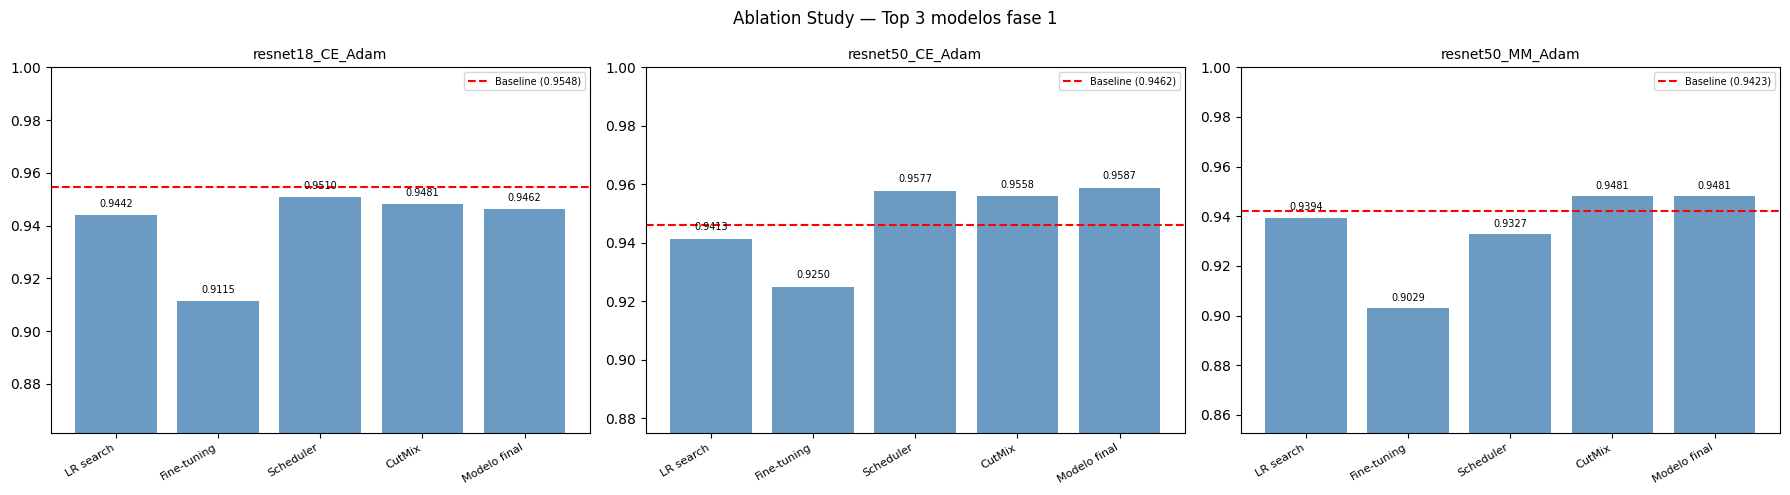

In [7]:
# ── Gráfico ablation por modelo ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics   = ["LR search acc", "Fine-tuning acc", "Scheduler acc", "CutMix acc", "Modelo final acc"]

for ax, row in zip(axes, all_ablation_rows):
    vals   = []
    labels = []
    for m in metrics:
        v = row.get(m)
        if v is not None and v != "N/A (MultiMarginLoss)":
            vals.append(float(v))
            labels.append(m.replace(" acc", ""))

    baseline = row["Baseline fase 1"]
    bars = ax.bar(labels, vals, color="steelblue", alpha=0.8)
    ax.axhline(y=baseline, color="red", linestyle="--", linewidth=1.5, label=f"Baseline ({baseline:.4f})")
    ax.set_title(row["Modelo"], fontsize=10)
    ax.set_ylim(max(0, min(vals) - 0.05), 1.0)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", fontsize=7)

plt.suptitle("Ablation Study — Top 3 modelos fase 1", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/ablation_top3.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Ensemble dos 3 modelos finais ──────────────────────────────────────────────
print("A construir ensemble dos 3 modelos finais...")

# Avaliar ensemble no val set
for m in final_models:
    m.eval()

all_preds, all_labels = [], []
cr_eval = get_criterion("CrossEntropyLoss")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        probs  = sum(
            torch.softmax(m(images), dim=1) for m in final_models
        ) / len(final_models)
        all_preds.extend(probs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

ens_acc = accuracy_score(all_labels, all_preds)
ens_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
print(f"\nEnsemble val — Acc: {ens_acc:.4f} | Macro F1: {ens_f1:.4f}")

# Submission ensemble com média das probabilidades já calculadas com TTA
avg_probs_ensemble = sum(final_probs_list) / len(final_probs_list)
preds_ensemble     = avg_probs_ensemble.argmax(axis=1)
labels_ensemble    = [idx_to_class[p] for p in preds_ensemble]

submission_ensemble = pd.DataFrame({
    "filename": filenames_test,
    "label":    labels_ensemble,
})
submission_ensemble.to_csv("../outputs/submissions/submission_ensemble_final.csv", index=False)
print(f"Submission ensemble guardada ({len(submission_ensemble)} linhas)")
submission_ensemble.head()

A construir ensemble dos 3 modelos finais...

Ensemble val — Acc: 0.9606 | Macro F1: 0.9612
Submission ensemble guardada (1300 linhas)


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_2.jpg,ZEBRA LONG WING
3,Image_3.jpg,COMMON BANDED AWL
4,Image_4.jpg,PAPER KITE


In [9]:
# ── Resumo final ───────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("RESUMO FINAL")
print("="*60)
for row in all_ablation_rows:
    print(f"  {row['Modelo']}")
    print(f"    Baseline fase 1  : {row['Baseline fase 1']:.4f}")
    print(f"    Modelo final acc : {row['Modelo final acc']:.4f}")
    print(f"    Modelo final F1  : {row['Modelo final F1']:.4f}")
    print(f"    Ganho            : {row['Ganho vs baseline']:+.4f}")
    print()
print(f"Ensemble final — Val Acc: {ens_acc:.4f} | Val F1: {ens_f1:.4f}")
print("\nSubmissions geradas:")
for cfg in TOP3:
    print(f"  ../outputs/submissions/submission_{cfg['id']}_final.csv")
print("  ../outputs/submissions/submission_ensemble_final.csv")


RESUMO FINAL
  resnet18_CE_Adam
    Baseline fase 1  : 0.9548
    Modelo final acc : 0.9462
    Modelo final F1  : 0.9462
    Ganho            : -0.0086

  resnet50_CE_Adam
    Baseline fase 1  : 0.9462
    Modelo final acc : 0.9587
    Modelo final F1  : 0.9598
    Ganho            : +0.0125

  resnet50_MM_Adam
    Baseline fase 1  : 0.9423
    Modelo final acc : 0.9481
    Modelo final F1  : 0.9485
    Ganho            : +0.0058

Ensemble final — Val Acc: 0.9606 | Val F1: 0.9612

Submissions geradas:
  ../outputs/submissions/submission_resnet18_CE_Adam_final.csv
  ../outputs/submissions/submission_resnet50_CE_Adam_final.csv
  ../outputs/submissions/submission_resnet50_MM_Adam_final.csv
  ../outputs/submissions/submission_ensemble_final.csv
